# Lab 02 — Supervised learning I: regression, classification, and the workflow

*Two regression examples, two classification examples, and a saved model at the end*

**Goal.** Fit and read a linear regression, validate a time series in date order, compare classifiers fairly, choose a decision threshold on purpose, tune with cross-validation on training data only, test once, and save the final models as files that can be loaded and used.

**Data.** `all_datasets/medical_cost_personal_dataset.csv`, `all_datasets/bike_sharing_dataset_day.csv`, `all_datasets/bike_sharing_dataset_hour.csv`, `all_datasets/titanic_dataset.csv`, `all_datasets/breast_cancer_dataset.csv`

**Reading.** Chapters 6–10 (How Supervised Learning Works; Evaluating Supervised Models; Training, Generalization, and Model Selection; Linear Models for Regression and for Classification)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab02/` — metrics table and the coefficient, residual, time-series, threshold, ROC/PR, and grid-search figures; `models/titanic_survival.joblib` and `models/insurance_charges.joblib` with the model card

**How much is scaffolded?** Fully worked. Parts A and B are regression, Parts C and D are classification, and Part E turns the results into files.

**Workflow**

1. Part A — Regression: ordinary least squares versus ridge
2. Part B — Regression on a time series: validate in date order
3. Part C — Classification: baselines, probabilities, and the threshold
4. Part D — Tune with cross-validation, then test once
5. Part E — Save the models and use them
6. Try it yourself, with one solution
7. Decision memo, with a model answer

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab02/`.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

RESULTS = PROJECT_ROOT / "results" / "lab02"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — Regression: ordinary least squares versus ridge

The insurance table has one row per customer and a numeric label, `charges`, so this is regression. Two models share the pipeline and the split; the only difference is ridge's penalty on large coefficients.

In [2]:
insurance = pd.read_csv(DATA / "medical_cost_personal_dataset.csv")
print(insurance.head())

X = insurance.drop(columns="charges")
y = insurance["charges"]
num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Three scores per model. MAE is the typical miss in dollars. RMSE weights big misses more, so when it is much larger than MAE a few predictions are badly wrong. $R^2$ is the share of the label's variation the model explains.

In [3]:
fitted = {}
predictions = {}

for name, estimator in {
    "linear regression": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
}.items():
    model = Pipeline([("preprocess", make_preprocess(num_cols, cat_cols)), ("model", estimator)])
    model.fit(X_train, y_train)
    fitted[name] = model
    predictions[name] = model.predict(X_valid)
    pred = predictions[name]
    print(f"\n{name}")
    print("MAE:", round(mean_absolute_error(y_valid, pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_valid, pred)), 2))
    print("R2:", round(r2_score(y_valid, pred), 3))


linear regression
MAE: 4181.19
RMSE: 5796.28
R2: 0.784

ridge
MAE: 4238.82
RMSE: 5821.59
R2: 0.782


A linear model is readable: each coefficient is the change in predicted charges for a one-unit change in that feature, the others held fixed. Because the numeric columns were standardized, one unit is one standard deviation, so the bars are comparable.

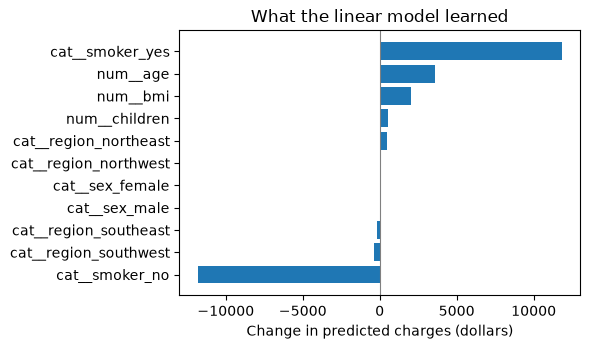

In [4]:
linear = fitted["linear regression"]
names = linear.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(linear.named_steps["model"].coef_, index=names).sort_values()

plt.figure(figsize=(6, 3.6))
plt.barh(coefs.index, coefs.values)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("Change in predicted charges (dollars)")
plt.title("What the linear model learned")
plt.tight_layout()
plt.savefig(RESULTS / "what_the_linear_model_learned.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** One bar dwarfs the rest: being a smoker adds well over \$20,000. Age and BMI matter, region barely does. A coefficient is an association inside this model, not a cause.

Two diagnostic plots for the ridge model. The residual plot should look like random scatter around zero; any pattern is something the model failed to use.

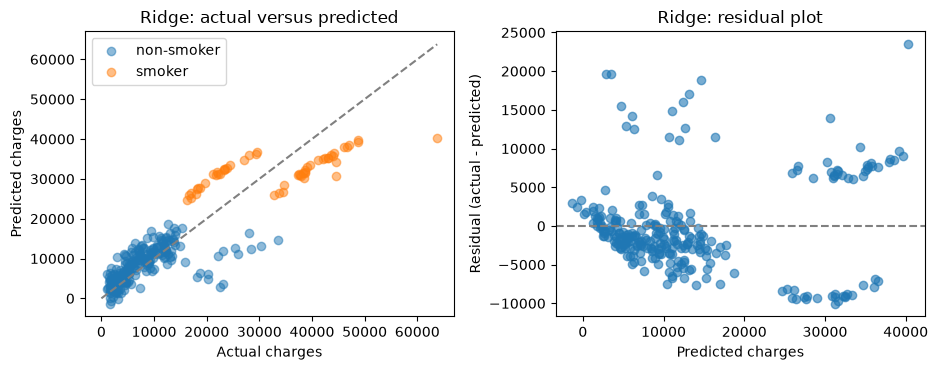

In [5]:
ridge_pred = predictions["ridge"]
residual = y_valid.to_numpy() - ridge_pred
is_smoker = (X_valid["smoker"] == "yes").to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].scatter(y_valid[~is_smoker], ridge_pred[~is_smoker], alpha=0.5, label="non-smoker")
axes[0].scatter(y_valid[is_smoker], ridge_pred[is_smoker], alpha=0.5, label="smoker")
axes[0].plot([0, y_valid.max()], [0, y_valid.max()], linestyle="--", color="grey")
axes[0].set_xlabel("Actual charges")
axes[0].set_ylabel("Predicted charges")
axes[0].set_title("Ridge: actual versus predicted")
axes[0].legend()
axes[1].scatter(ridge_pred, residual, alpha=0.6)
axes[1].axhline(0, linestyle="--", color="grey")
axes[1].set_xlabel("Predicted charges")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Ridge: residual plot")
plt.tight_layout()
plt.savefig(RESULTS / "ridge_residual_plot.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Smokers form a separate, expensive band, and one straight surface cannot fit both bands: the residuals form stripes rather than a cloud. That is a missing interaction (smoker × BMI), and no amount of regularization will fix it; a new feature or a non-linear model will.

**What the output shows.** Linear regression: MAE 4,181, R² 0.784. Ridge (alpha 10): MAE 4,239, R² 0.782. Regularization did not help; with 1,070 rows and eleven encoded columns the plain model is already stable. The coefficient plot shows smoking adding over \$23,000. The residual stripes are the two-band problem: a missing smoker × BMI interaction that no penalty can fix.

## Part B — Regression on a time series: validate in date order

Bike rentals are recorded per day for two years. A random split would let the model train on days that come *after* the ones it is validated on, which never happens in real use. So the rows are sorted by date and the last 20% of days form the validation set.

In [6]:
bikes = pd.read_csv(DATA / "bike_sharing_dataset_day.csv")
bikes["dteday"] = pd.to_datetime(bikes["dteday"])
bikes = bikes.sort_values("dteday").reset_index(drop=True)

# cnt = casual + registered, so those two columns would leak the answer.
bike_cat = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
bike_num = ["temp", "atemp", "hum", "windspeed"]
X_b = bikes[bike_cat + bike_num]
y_b = bikes["cnt"]

cut = int(len(bikes) * 0.80)
print("train:", bikes["dteday"].iloc[0].date(), "to", bikes["dteday"].iloc[cut - 1].date())
print("valid:", bikes["dteday"].iloc[cut].date(), "to", bikes["dteday"].iloc[-1].date())

train: 2011-01-01 to 2012-08-06
valid: 2012-08-07 to 2012-12-31


The calendar columns are categories (month 12 is not “twelve times” month 1), so they are one-hot encoded. The weather columns are already numbers between 0 and 1, and trees do not need scaling, so those pass straight through.

daily MAE: 1040.4  (mean daily demand in validation: 5897.8 )


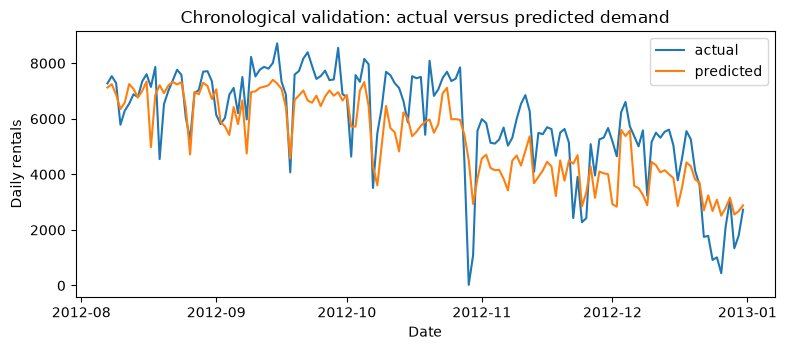

In [7]:
Xb_train, Xb_valid = X_b.iloc[:cut], X_b.iloc[cut:]
yb_train, yb_valid = y_b.iloc[:cut], y_b.iloc[cut:]
dates_valid = bikes["dteday"].iloc[cut:]

bike_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), bike_cat),
        ("num", "passthrough", bike_num),
    ])),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
])
bike_model.fit(Xb_train, yb_train)
bike_pred = bike_model.predict(Xb_valid)
print("daily MAE:", round(mean_absolute_error(yb_valid, bike_pred), 1),
      " (mean daily demand in validation:", round(yb_valid.mean(), 1), ")")

plt.figure(figsize=(8, 3.6))
plt.plot(dates_valid, yb_valid.to_numpy(), label="actual")
plt.plot(dates_valid, bike_pred, label="predicted")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.title("Chronological validation: actual versus predicted demand")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "chronological_validation_actual_versus_predicted_demand.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The model tracks the weekly rhythm and the winter decline, but it under-predicts the autumn peak: those days were busier than anything in the training period, and a forest cannot predict values it has never seen. A random split would have hidden this weakness.

The same split rule on the hourly file (17,379 rows) with one new feature, `hr`. One validation week, hour by hour, shows what the daily plot averages away.

hourly MAE: 56.5  (mean hourly demand in validation: 248.8 )


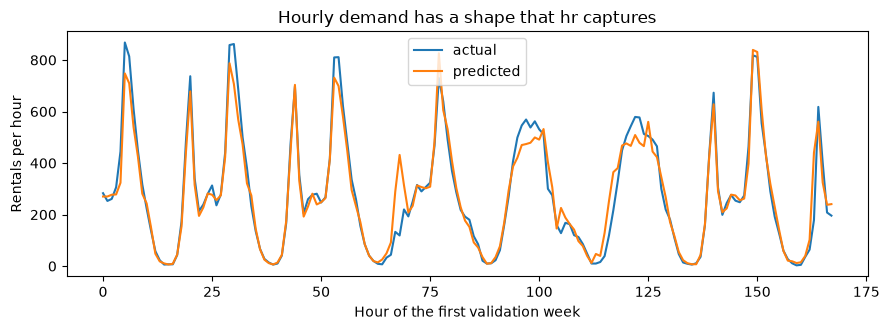

In [8]:
hourly = pd.read_csv(DATA / "bike_sharing_dataset_hour.csv")
hourly["dteday"] = pd.to_datetime(hourly["dteday"])
hourly = hourly.sort_values(["dteday", "hr"]).reset_index(drop=True)

hour_cat = bike_cat + ["hr"]
Xh = hourly[hour_cat + bike_num]
yh = hourly["cnt"]
cut_h = int(len(hourly) * 0.80)

hour_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), hour_cat),
        ("num", "passthrough", bike_num),
    ])),
    ("model", RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
])
hour_model.fit(Xh.iloc[:cut_h], yh.iloc[:cut_h])
hour_pred = hour_model.predict(Xh.iloc[cut_h:])
print("hourly MAE:", round(mean_absolute_error(yh.iloc[cut_h:], hour_pred), 1),
      " (mean hourly demand in validation:", round(yh.iloc[cut_h:].mean(), 1), ")")

week = slice(0, 24 * 7)
plt.figure(figsize=(9, 3.4))
plt.plot(range(24 * 7), yh.iloc[cut_h:].to_numpy()[week], label="actual")
plt.plot(range(24 * 7), hour_pred[week], label="predicted")
plt.xlabel("Hour of the first validation week")
plt.ylabel("Rentals per hour")
plt.title("Hourly demand has a shape that hr captures")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "hourly_demand_has_a_shape_that_hr_captures.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Two rush-hour peaks on working days, one broad hump at the weekend. Lab 8 forecasts this same series with a recurrent network from the previous 24 hours alone.

**What the output shows.** Daily: MAE 1,040 rentals on the last 147 days, with the autumn peak under-predicted because trees cannot extrapolate. Hourly: MAE 56 rides against a mean of 249, with `hr` capturing the two rush-hour peaks. A random split would have hidden the daily model's weakness.

## Part C — Classification: baselines, probabilities, and the threshold

Seven passenger columns are the features; identifiers stay out. `stratify=y` keeps the survival rate the same in both halves of the split. Logistic regression is the simple, readable reference; a random forest is the more flexible challenger. Accuracy counts correct decisions at the default 0.5 cutoff; ROC AUC judges how well the model *ranks* passengers, independent of any cutoff.

majority-class baseline accuracy: 0.614
logistic       accuracy=0.776 roc_auc=0.842


random_forest  accuracy=0.798 roc_auc=0.834
threshold 0.30: precision=0.64 recall=0.81
threshold 0.50: precision=0.72 recall=0.67
threshold 0.70: precision=0.90 recall=0.50


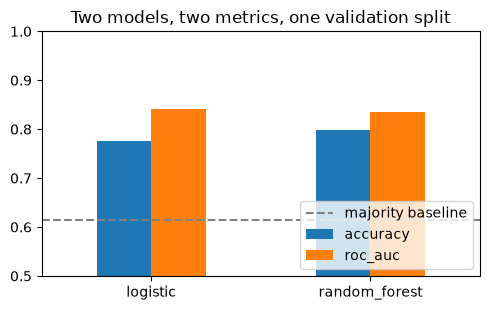

In [9]:
titanic = pd.read_csv(DATA / "titanic_dataset.csv")

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
t_num = ["Age", "SibSp", "Parch", "Fare"]
t_cat = ["Pclass", "Sex", "Embarked"]
X_t = titanic[features]
y_t = titanic["Survived"]

Xt_train, Xt_valid, yt_train, yt_valid = train_test_split(
    X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)
print("majority-class baseline accuracy:", round(1 - yt_valid.mean(), 3))

scores = {}
fitted_t = {}
for name, estimator in {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            random_state=42),
}.items():
    pipe = Pipeline([("preprocess", make_preprocess(t_num, t_cat)), ("model", estimator)])
    pipe.fit(Xt_train, yt_train)
    fitted_t[name] = pipe
    scores[name] = {"accuracy": accuracy_score(yt_valid, pipe.predict(Xt_valid)),
                    "roc_auc": roc_auc_score(yt_valid, pipe.predict_proba(Xt_valid)[:, 1])}
    print(f"{name:14s} accuracy={scores[name]['accuracy']:.3f} "
          f"roc_auc={scores[name]['roc_auc']:.3f}")

# The same logistic model, three decision rules (the table in the notes).
prob_t = fitted_t["logistic"].predict_proba(Xt_valid)[:, 1]
for threshold in [0.30, 0.50, 0.70]:
    pred_t = (prob_t >= threshold).astype(int)
    print(f"threshold {threshold:.2f}: precision={precision_score(yt_valid, pred_t):.2f} "
          f"recall={recall_score(yt_valid, pred_t):.2f}")

pd.DataFrame(scores).T.plot.bar(figsize=(5, 3.2), ylim=(0.5, 1.0), rot=0)
plt.axhline(1 - yt_valid.mean(), linestyle="--", color="grey", label="majority baseline")
plt.title("Two models, two metrics, one validation split")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS / "two_models_two_metrics_one_validation_split.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Both models clear the baseline by a wide margin, but the two metrics disagree about which is better. On 223 validation rows a gap of two points is within noise; Part D settles the choice with cross-validation.

Now the breast-cancer table: 30 numeric measurements and a label `M` (malignant) or `B` (benign). The model outputs a probability for every tumour. Plotting those probabilities separately for benign and malignant cases shows what a threshold actually does: it is a vertical line, and everything to its right is called malignant.

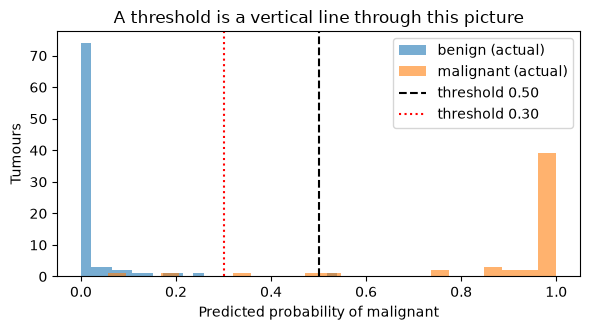

In [10]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")

X_c = cancer.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y_c = (cancer["diagnosis"] == "M").astype(int)

Xc_train, Xc_valid, yc_train, yc_valid = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

cancer_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000)),
])
cancer_model.fit(Xc_train, yc_train)
prob = cancer_model.predict_proba(Xc_valid)[:, 1]

plt.figure(figsize=(6, 3.4))
plt.hist(prob[yc_valid == 0], bins=25, alpha=0.6, label="benign (actual)")
plt.hist(prob[yc_valid == 1], bins=25, alpha=0.6, label="malignant (actual)")
plt.axvline(0.50, color="black", linestyle="--", label="threshold 0.50")
plt.axvline(0.30, color="red", linestyle=":", label="threshold 0.30")
plt.xlabel("Predicted probability of malignant")
plt.ylabel("Tumours")
plt.title("A threshold is a vertical line through this picture")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "a_threshold_is_a_vertical_line_through_this_picture.png", dpi=160, bbox_inches="tight")
plt.show()

The confusion matrix counts what happens on each side of the line: rows are the truth, columns are the decision. Precision is “when the model says malignant, how often is it right?”; recall is “of the malignant tumours, how many did it find?”. Lowering the threshold raises recall and lowers precision.


threshold = 0.50
[[89  1]
 [ 4 49]]
              precision    recall  f1-score   support

           0      0.957     0.989     0.973        90
           1      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143



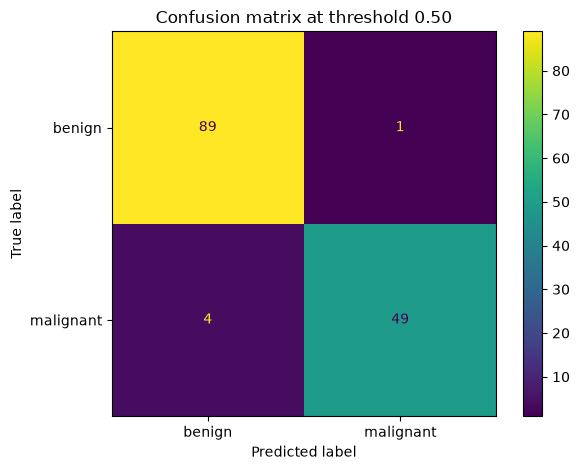


threshold = 0.30
[[89  1]
 [ 2 51]]
              precision    recall  f1-score   support

           0      0.978     0.989     0.983        90
           1      0.981     0.962     0.971        53

    accuracy                          0.979       143
   macro avg      0.979     0.976     0.977       143
weighted avg      0.979     0.979     0.979       143



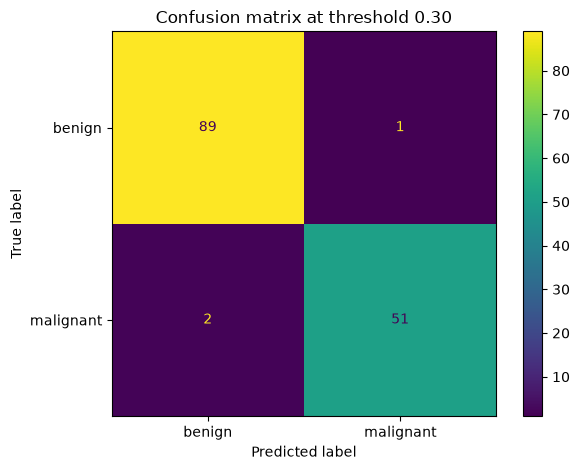

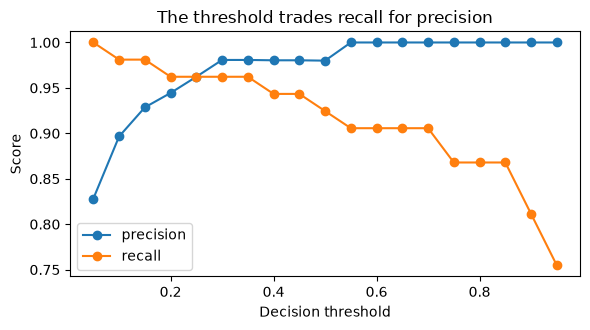

In [11]:
for threshold in [0.50, 0.30]:
    pred = (prob >= threshold).astype(int)
    print(f"\nthreshold = {threshold:.2f}")
    print(confusion_matrix(yc_valid, pred))
    print(classification_report(yc_valid, pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(yc_valid, pred, display_labels=["benign", "malignant"])
    plt.title(f"Confusion matrix at threshold {threshold:.2f}")
    plt.tight_layout()
    plt.savefig(RESULTS / f"confusion_matrix_at_threshold_{threshold:.2f}.png", dpi=160, bbox_inches="tight")
    plt.show()

thresholds = np.linspace(0.05, 0.95, 19)
precisions = [precision_score(yc_valid, (prob >= t).astype(int), zero_division=0)
              for t in thresholds]
recalls = [recall_score(yc_valid, (prob >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(6, 3.4))
plt.plot(thresholds, precisions, marker="o", label="precision")
plt.plot(thresholds, recalls, marker="o", label="recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("The threshold trades recall for precision")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "the_threshold_trades_recall_for_precision.png", dpi=160, bbox_inches="tight")
plt.show()

Two metrics summarise the ranking without choosing any threshold. ROC AUC is the chance that a random malignant tumour scores higher than a random benign one. Average precision (PR AUC) focuses on the positive class and is the more honest number when positives are rare.

ROC AUC: 0.996
PR AUC: 0.994


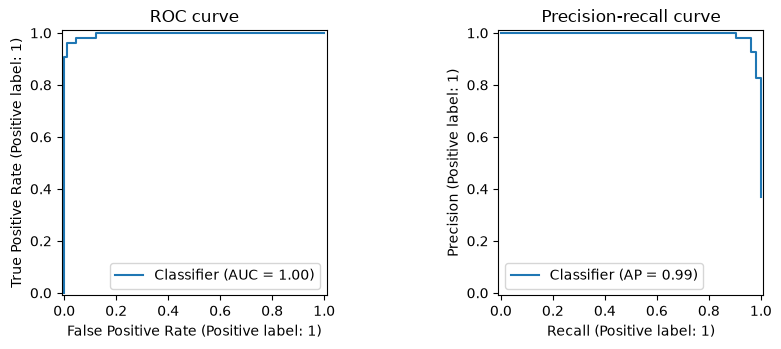

In [12]:
print("ROC AUC:", round(roc_auc_score(yc_valid, prob), 3))
print("PR AUC:", round(average_precision_score(yc_valid, prob), 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
RocCurveDisplay.from_predictions(yc_valid, prob, ax=axes[0])
axes[0].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(yc_valid, prob, ax=axes[1])
axes[1].set_title("Precision-recall curve")
plt.tight_layout()
plt.savefig(RESULTS / "precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

**What the output shows.** Titanic: logistic accuracy 0.776 / ROC AUC 0.842, random forest 0.798 / 0.834, majority baseline 0.614; the metrics disagree and the gap is within noise. The three-threshold table for the logistic model (0.30: precision 0.64, recall 0.81; 0.50: 0.73, 0.67; 0.70: 0.90, 0.50) is the one Chapter 10 quotes. Breast cancer: at 0.50 the model misses 4 of 53 malignant tumours with 1 false alarm; at 0.30 it misses 2 with the same 1 false alarm. ROC AUC 0.996 and PR AUC 0.994 say the ranking is almost perfect; the remaining errors are about where the cut is.

## Part D — Tune with cross-validation, then test once

Back to Titanic, with a new split whose second half is now the *test* set: it is opened once, at the very end. Inside the training half, five-fold cross-validation scores every combination of `C` (regularization strength) and `class_weight`. The grid search then refits the winning combination on all training rows.

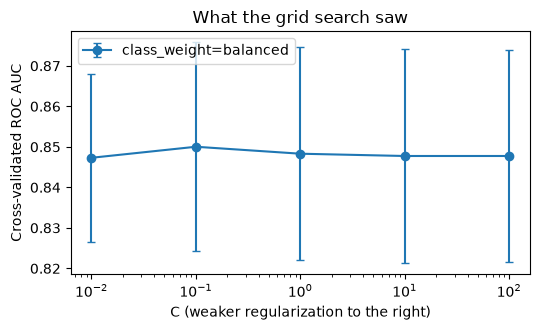

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)

search = GridSearchCV(
    Pipeline([("preprocess", make_preprocess(t_num, t_cat)),
              ("model", LogisticRegression(max_iter=2000))]),
    param_grid={
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__class_weight": [None, "balanced"],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)
search.fit(X_train, y_train)

cv_table = pd.DataFrame(search.cv_results_)
plt.figure(figsize=(5.5, 3.4))
for weight, group in cv_table.groupby(cv_table["param_model__class_weight"].astype(str)):
    plt.errorbar(group["param_model__C"].astype(float), group["mean_test_score"],
                 yerr=group["std_test_score"], marker="o", capsize=3, label=f"class_weight={weight}")
plt.xscale("log")
plt.xlabel("C (weaker regularization to the right)")
plt.ylabel("Cross-validated ROC AUC")
plt.title("What the grid search saw")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "what_the_grid_search_saw.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The curve is flat across most of the grid: this dataset does not care much about `C`. The error bars, one standard deviation across the five folds, are wider than the gaps between settings, which is a reminder not to over-read small differences.

Only now is the test set touched, once.

In [14]:
test_prob = search.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)

print("best parameters:", search.best_params_)
print("cross-validated ROC AUC:", round(search.best_score_, 3))
print("final test ROC AUC:", round(test_auc, 3))

best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
cross-validated ROC AUC: 0.85
final test ROC AUC: 0.837


**What the output shows.** The search picks `C = 0.1` with balanced class weights: cross-validated ROC AUC 0.850, then a single test ROC AUC of 0.837. The test score is a little lower, as expected, because the CV score was used to pick the best of ten options. Report the test number once and do not tune again after seeing it.

## Part E — Save the models and use them

A model that exists only inside a running notebook is not finished. `joblib.dump` writes the whole pipeline, preprocessing and estimator together, to one file. A model card written next to it records what the file expects and how well it did, so someone else can use it safely.

In [15]:
final_model = search.best_estimator_
model_path = MODELS / "titanic_survival.joblib"
joblib.dump(final_model, model_path)

card = {
    "task": "predict Titanic survival (1 = survived)",
    "features": features,
    "model": "logistic regression pipeline",
    "best_parameters": search.best_params_,
    "training_rows": int(len(X_train)),
    "final_test_roc_auc": round(float(test_auc), 3),
    "decision_threshold": 0.5,
    "scikit_learn_version": sklearn.__version__,
}
(MODELS / "titanic_survival_card.json").write_text(json.dumps(card, indent=2))
size_kb = model_path.stat().st_size / 1024
print(f"saved: {model_path.name} ({size_kb:.1f} KB) and titanic_survival_card.json")

saved: titanic_survival.joblib (4.5 KB) and titanic_survival_card.json


Deployment, in its smallest form, is three lines: load the file, hand it new rows with the same column names, read the predictions. No retraining and no preprocessing code, because the preprocessing travelled inside the file. The insurance model is saved the same way and used to price two customers who differ only in one column.

In [16]:
loaded = joblib.load(model_path)
new_passengers = pd.DataFrame([
    {"Pclass": 1, "Sex": "female", "Age": 29, "SibSp": 0, "Parch": 0, "Fare": 80.0, "Embarked": "C"},
    {"Pclass": 3, "Sex": "male",   "Age": 40, "SibSp": 0, "Parch": 0, "Fare":  7.9, "Embarked": "S"},
])
new_passengers["survival_probability"] = loaded.predict_proba(new_passengers)[:, 1].round(3)
print(new_passengers)

joblib.dump(fitted["linear regression"], MODELS / "insurance_charges.joblib")
pricing = joblib.load(MODELS / "insurance_charges.joblib")
new_customer = pd.DataFrame([
    {"age": 35, "sex": "female", "bmi": 27.5, "children": 2, "smoker": "no", "region": "southeast"},
    {"age": 35, "sex": "female", "bmi": 27.5, "children": 2, "smoker": "yes", "region": "southeast"},
])
new_customer["predicted_charges"] = pricing.predict(new_customer).round(0)
print(new_customer)

   Pclass     Sex  Age  SibSp  Parch  Fare Embarked  survival_probability
0       1  female   29      0      0  80.0        C                 0.942
1       3    male   40      0      0   7.9        S                 0.141
   age     sex   bmi  children smoker     region  predicted_charges
0   35  female  27.5         2     no  southeast             6526.0
1   35  female  27.5         2    yes  southeast            30177.0


The script `all_experiments/predict_passenger.py` does the same job from the terminal, so anyone with the model file can use it without opening a notebook:

```bash
python predict_passenger.py --pclass 2 --sex female --age 30 --fare 20
```

**What the output shows.** `titanic_survival.joblib` is about 5 KB and contains the imputers, the scaler, the encoder, and the classifier. The reloaded model gives a first-class woman a 94% chance of survival and a third-class man 14%; the insurance model prices the same customer at about \$6,500 as a non-smoker and \$30,200 as a smoker. `predict_passenger.py` in this folder uses the Titanic file and its card from the terminal.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [17]:
rows = [{"part": "A", "dataset": "medical_cost", "model": name, "metric": "mae",
         "validation": mean_absolute_error(y_valid, p)} for name, p in predictions.items()]
rows.append({"part": "B", "dataset": "bike_sharing_day", "model": "random_forest (chronological)", "metric": "mae",
             "validation": mean_absolute_error(yb_valid, bike_pred)})
rows.append({"part": "B", "dataset": "bike_sharing_hour", "model": "random_forest (chronological)", "metric": "mae",
             "validation": mean_absolute_error(yh.iloc[cut_h:], hour_pred)})
rows += [{"part": "C", "dataset": "titanic", "model": name, "metric": "roc_auc", "validation": s["roc_auc"]}
         for name, s in scores.items()]
rows.append({"part": "C", "dataset": "breast_cancer", "model": "logistic", "metric": "roc_auc",
             "validation": roc_auc_score(yc_valid, prob)})
rows.append({"part": "D", "dataset": "titanic", "model": f"logistic {search.best_params_}", "metric": "roc_auc",
             "validation": search.best_score_, "test": test_auc})
pd.DataFrame(rows).round(4).to_csv(RESULTS / "metrics.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
print("Model files:", sorted(p.name for p in MODELS.iterdir() if p.suffix in {".joblib", ".json"}))

Saved: ['a_threshold_is_a_vertical_line_through_this_picture.png', 'chronological_validation_actual_versus_predicted_demand.png', 'confusion_matrix_at_threshold_0.30.png', 'confusion_matrix_at_threshold_0.50.png', 'hourly_demand_has_a_shape_that_hr_captures.png', 'metrics.csv', 'precision_recall_curve.png', 'ridge_residual_plot.png', 'the_threshold_trades_recall_for_precision.png', 'two_models_two_metrics_one_validation_split.png', 'what_the_grid_search_saw.png', 'what_the_linear_model_learned.png']
Model files: ['bike_lstm_card.json', 'breast_cancer_svm.joblib', 'digits_cnn_card.json', 'digits_pca_logistic.joblib', 'insurance_charges.joblib', 'titanic_survival.joblib', 'titanic_survival_card.json']


## Try it yourself

Run the Part C classification workflow on `heart_failure_dataset.csv` (label `HeartDisease`). Build the column lists from the data types with `select_dtypes`, reuse `make_preprocess`, and report accuracy, ROC AUC, and the confusion matrix at threshold 0.5.

Attempt it in the cell below before reading the solution.

In [18]:
# Your work here


## Decision memo

Choose a classification threshold for a setting in which a missed positive costs much more than a false alarm. State what happens to the confusion matrix when the threshold is lowered, and name the validation evidence from Part C that supports your choice.

Write your own memo first; a model answer follows the solution.

**Threshold chosen:**

**Evidence used:**

**What lowering the threshold does:**


### One solution

The same classification workflow on the heart-failure table. The column lists come from the data types, so nothing needs editing by hand.

numeric: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
text: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
majority baseline accuracy: 0.552
accuracy: 0.883  ROC AUC: 0.932
              precision    recall  f1-score   support

           0      0.896     0.835     0.864       103
           1      0.873     0.921     0.897       127

    accuracy                          0.883       230
   macro avg      0.884     0.878     0.880       230
weighted avg      0.883     0.883     0.882       230



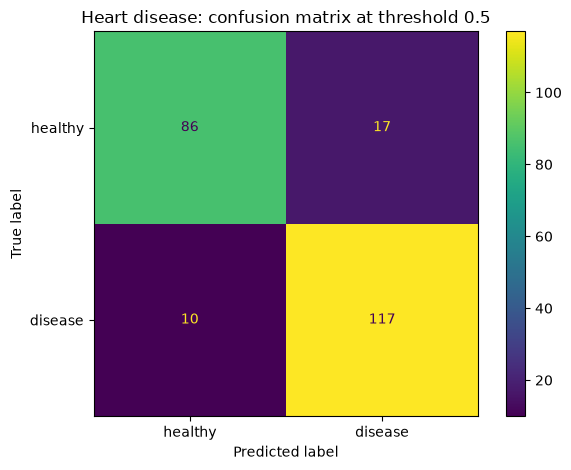

In [19]:
heart = pd.read_csv(DATA / "heart_failure_dataset.csv")
X_h = heart.drop(columns="HeartDisease")
y_h = heart["HeartDisease"]
h_num = X_h.select_dtypes(include="number").columns.tolist()
h_cat = X_h.select_dtypes(exclude="number").columns.tolist()
print("numeric:", h_num)
print("text:", h_cat)

Xh_train, Xh_valid, yh_train, yh_valid = train_test_split(X_h, y_h, test_size=0.25, random_state=42, stratify=y_h)
heart_model = Pipeline([("preprocess", make_preprocess(h_num, h_cat)),
                        ("model", LogisticRegression(max_iter=2000))]).fit(Xh_train, yh_train)
prob_h = heart_model.predict_proba(Xh_valid)[:, 1]
pred_h = (prob_h >= 0.50).astype(int)
print("majority baseline accuracy:", round(max(yh_valid.mean(), 1 - yh_valid.mean()), 3))
print("accuracy:", round(accuracy_score(yh_valid, pred_h), 3), " ROC AUC:", round(roc_auc_score(yh_valid, prob_h), 3))
print(classification_report(yh_valid, pred_h, digits=3))
ConfusionMatrixDisplay.from_predictions(yh_valid, pred_h, display_labels=["healthy", "disease"])
plt.title("Heart disease: confusion matrix at threshold 0.5")
plt.tight_layout()
plt.savefig(RESULTS / "heart_disease_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

**What it shows.** Accuracy 0.883 and ROC AUC 0.932 against a majority baseline of 0.552, with recall 0.921 for the disease class at the default threshold. Nothing in the modelling code changed except the target column name: the helper discovered five text and six numeric columns on its own. That portability is the point of putting the preprocessing inside the estimator.

### A model decision memo

**Threshold chosen:** 0.30 for the breast-cancer screener.

**Evidence used (Part C):** on the validation split the default threshold of 0.50 misses 4 of 53 malignant tumours with 1 false alarm. Lowering it to 0.30 recovers two of those misses (recall rises from 0.925 to 0.962) with no extra false alarms. Going further to 0.20 catches nothing more and only adds false alarms. ROC AUC 0.996 and PR AUC 0.994 say the model ranks tumours almost perfectly, so the remaining errors are about where the cut sits, not about the model.

**What lowering the threshold does:** the decision line moves left through the probability histogram, so more tumours are called malignant; the false-negative cell of the confusion matrix shrinks and the false-positive cell grows. In screening, a false alarm costs a follow-up test while a miss can cost a life, so trading a few false alarms for fewer misses is the right direction, and 0.30 is where the validation evidence says the trade stops paying.